# EDA 9.1: Conversion Proxy and Traffic Quality Deterioration

This notebook tests the hypothesis that traffic growth stopped converting efficiently into purchase behavior.

Core proxy:

`Conversion Proxy = Orders / Sessions`

The goal is descriptive validation for the analytics narrative: traffic continued to grow after 2017, but order volume, revenue per session, and conversion proxy deteriorated materially.


## 1. Setup and Data Loading

Required files:
- `web_traffic.csv` for sessions and traffic source
- `orders.csv` for order count and order source
- `sales.csv` for revenue, revenue per session, and AOV context

Methodological note: `web_traffic.csv` starts in 2013, while sales/orders begin mid-2012. All indexed comparisons therefore use 2013 as the common baseline.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if not (ROOT / "datathon-2026-round-1").exists() and (ROOT / "ai_eda").exists():
    ROOT = ROOT / "ai_eda"
if not (ROOT / "datathon-2026-round-1").exists() and Path("Datathon-2026-Inlier/ai_eda").exists():
    ROOT = Path("Datathon-2026-Inlier/ai_eda")

DATA_DIR = ROOT / "datathon-2026-round-1"
OUT_DIR = ROOT / "report_visuals"
OUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (13, 7),
    "figure.dpi": 130,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E7E9ED",
    "grid.linewidth": 0.8,
    "font.family": "Arial",
})
sns.set_theme(style="whitegrid")

sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"])
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])

print("sales:", sales.shape, sales["Date"].min().date(), "to", sales["Date"].max().date())
print("orders:", orders.shape, orders["order_date"].min().date(), "to", orders["order_date"].max().date())
print("traffic:", traffic.shape, traffic["date"].min().date(), "to", traffic["date"].max().date())


sales: (3833, 3) 2012-07-04 to 2022-12-31
orders: (646945, 8) 2012-07-04 to 2022-12-31
traffic: (3652, 7) 2013-01-01 to 2022-12-31


## 2. Build Daily, Monthly, and Annual Conversion Proxy

The primary metric is total orders divided by total sessions over the same period. Revenue and AOV are added as supporting diagnostics, not as inputs to the proxy.


In [2]:
completed_statuses = {"delivered", "shipped", "paid"}

daily_sessions = (
    traffic.groupby("date", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        avg_bounce_rate=("bounce_rate", "mean"),
        avg_session_duration_sec=("avg_session_duration_sec", "mean"),
    )
    .rename(columns={"date": "Date"})
)

daily_orders = (
    orders.assign(
        Date=orders["order_date"].dt.floor("D"),
        completed_order=orders["order_status"].str.lower().isin(completed_statuses),
    )
    .groupby("Date", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        completed_orders=("completed_order", "sum"),
    )
)

daily_revenue = (
    sales.groupby("Date", as_index=False)
    .agg(revenue=("Revenue", "sum"), cogs=("COGS", "sum"))
)

daily = (
    daily_sessions
    .merge(daily_orders, on="Date", how="left")
    .merge(daily_revenue, on="Date", how="left")
    .fillna({"orders": 0, "completed_orders": 0, "revenue": 0, "cogs": 0})
)

daily["conversion_proxy"] = daily["orders"] / daily["sessions"]
daily["completed_conversion_proxy"] = daily["completed_orders"] / daily["sessions"]
daily["revenue_per_session"] = daily["revenue"] / daily["sessions"]
daily["aov"] = daily["revenue"] / daily["orders"].replace(0, np.nan)
daily["Year"] = daily["Date"].dt.year
daily["Month"] = daily["Date"].dt.to_period("M").dt.to_timestamp()

monthly = (
    daily.groupby("Month", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        orders=("orders", "sum"),
        completed_orders=("completed_orders", "sum"),
        revenue=("revenue", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        avg_bounce_rate=("avg_bounce_rate", "mean"),
        avg_session_duration_sec=("avg_session_duration_sec", "mean"),
    )
)
monthly["conversion_proxy"] = monthly["orders"] / monthly["sessions"]
monthly["completed_conversion_proxy"] = monthly["completed_orders"] / monthly["sessions"]
monthly["revenue_per_session"] = monthly["revenue"] / monthly["sessions"]
monthly["aov"] = monthly["revenue"] / monthly["orders"].replace(0, np.nan)

annual = (
    daily.groupby("Year", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        orders=("orders", "sum"),
        completed_orders=("completed_orders", "sum"),
        revenue=("revenue", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        avg_bounce_rate=("avg_bounce_rate", "mean"),
        avg_session_duration_sec=("avg_session_duration_sec", "mean"),
    )
    .query("Year >= 2013 and Year <= 2022")
)
annual["conversion_proxy"] = annual["orders"] / annual["sessions"]
annual["completed_conversion_proxy"] = annual["completed_orders"] / annual["sessions"]
annual["revenue_per_session"] = annual["revenue"] / annual["sessions"]
annual["aov"] = annual["revenue"] / annual["orders"].replace(0, np.nan)

baseline_year = 2013
index_cols = ["sessions", "orders", "completed_orders", "revenue", "conversion_proxy", "completed_conversion_proxy", "revenue_per_session", "aov"]
for col in index_cols:
    annual[f"{col}_index"] = annual[col] / annual.loc[annual["Year"].eq(baseline_year), col].iloc[0] * 100

annual["conversion_proxy_pct"] = annual["conversion_proxy"] * 100
annual["completed_conversion_proxy_pct"] = annual["completed_conversion_proxy"] * 100
annual["revenue_per_1k_sessions"] = annual["revenue_per_session"] * 1000
annual.to_csv(OUT_DIR / "conversion_proxy_annual_metrics.csv", index=False)

display_cols = [
    "Year", "sessions", "orders", "revenue", "conversion_proxy_pct",
    "sessions_index", "orders_index", "conversion_proxy_index",
    "revenue_per_session_index", "aov_index"
]
annual[display_cols].round(2)


,Year,sessions,orders,revenue,conversion_proxy_pct,sessions_index,orders_index,conversion_proxy_index,revenue_per_session_index,aov_index
0,2013,6801940,76849,1.657169e+09,1.13,100.00,100.00,100.00,100.00,100.00
1,2014,7340960,80645,1.871846e+09,1.10,107.92,104.94,97.23,104.66,107.64
2,2015,7861938,82622,1.889934e+09,1.05,115.58,107.51,93.02,98.67,106.08
3,2016,8403399,82247,2.104641e+09,0.98,123.54,107.02,86.63,102.80,118.67
4,2017,8992602,76010,1.911164e+09,0.85,132.21,98.91,74.81,87.23,116.60
5,2018,9415085,69510,1.850122e+09,0.74,138.42,90.45,65.35,80.66,123.43
6,2019,9990148,41601,1.136801e+09,0.42,146.87,54.13,36.86,46.71,126.72
7,2020,10591082,34881,1.054512e+09,0.33,155.71,45.39,29.15,40.87,140.20
8,2021,10991725,34525,1.043040e+09,0.31,161.60,44.93,27.80,38.95,140.10
9,2022,11063658,36004,1.169749e+09,0.33,162.65,46.85,28.80,43.40,150.67


## 3. Executive Readout

This section quantifies the divergence: traffic rises, while order conversion and revenue yield per session decline.


In [3]:
def pct_change_between(df, col, start_year, end_year):
    start = df.loc[df["Year"].eq(start_year), col].iloc[0]
    end = df.loc[df["Year"].eq(end_year), col].iloc[0]
    return (end / start - 1) * 100

pre_2017 = annual.query("Year <= 2017")
divergence = annual.query("Year >= 2019")

summary = pd.DataFrame({
    "metric": [
        "Sessions",
        "Orders",
        "Revenue",
        "Conversion Proxy",
        "Revenue / Session",
        "AOV",
    ],
    "2013_index": [
        annual.loc[annual["Year"].eq(2013), "sessions_index"].iloc[0],
        annual.loc[annual["Year"].eq(2013), "orders_index"].iloc[0],
        annual.loc[annual["Year"].eq(2013), "revenue_index"].iloc[0],
        annual.loc[annual["Year"].eq(2013), "conversion_proxy_index"].iloc[0],
        annual.loc[annual["Year"].eq(2013), "revenue_per_session_index"].iloc[0],
        annual.loc[annual["Year"].eq(2013), "aov_index"].iloc[0],
    ],
    "2017_index": [
        annual.loc[annual["Year"].eq(2017), "sessions_index"].iloc[0],
        annual.loc[annual["Year"].eq(2017), "orders_index"].iloc[0],
        annual.loc[annual["Year"].eq(2017), "revenue_index"].iloc[0],
        annual.loc[annual["Year"].eq(2017), "conversion_proxy_index"].iloc[0],
        annual.loc[annual["Year"].eq(2017), "revenue_per_session_index"].iloc[0],
        annual.loc[annual["Year"].eq(2017), "aov_index"].iloc[0],
    ],
    "2022_index": [
        annual.loc[annual["Year"].eq(2022), "sessions_index"].iloc[0],
        annual.loc[annual["Year"].eq(2022), "orders_index"].iloc[0],
        annual.loc[annual["Year"].eq(2022), "revenue_index"].iloc[0],
        annual.loc[annual["Year"].eq(2022), "conversion_proxy_index"].iloc[0],
        annual.loc[annual["Year"].eq(2022), "revenue_per_session_index"].iloc[0],
        annual.loc[annual["Year"].eq(2022), "aov_index"].iloc[0],
    ],
})
summary["change_2017_to_2022_pct"] = (summary["2022_index"] / summary["2017_index"] - 1) * 100
summary.round(1)


,metric,2013_index,2017_index,2022_index,change_2017_to_2022_pct
0,Sessions,100.0,132.2,162.7,23.0
1,Orders,100.0,98.9,46.9,-52.6
2,Revenue,100.0,115.3,70.6,-38.8
3,Conversion Proxy,100.0,74.8,28.8,-61.5
4,Revenue / Session,100.0,87.2,43.4,-50.3
5,AOV,100.0,116.6,150.7,29.2


In [4]:
cp_2013 = annual.loc[annual["Year"].eq(2013), "conversion_proxy_pct"].iloc[0]
cp_2017 = annual.loc[annual["Year"].eq(2017), "conversion_proxy_pct"].iloc[0]
cp_2022 = annual.loc[annual["Year"].eq(2022), "conversion_proxy_pct"].iloc[0]
sessions_2017_2022 = pct_change_between(annual, "sessions", 2017, 2022)
orders_2017_2022 = pct_change_between(annual, "orders", 2017, 2022)
revenue_2017_2022 = pct_change_between(annual, "revenue", 2017, 2022)
rps_2017_2022 = pct_change_between(annual, "revenue_per_session", 2017, 2022)

print(f"Conversion proxy fell from {cp_2017:.3f}% in 2017 to {cp_2022:.3f}% in 2022.")
print(f"From 2017 to 2022, sessions grew {sessions_2017_2022:.1f}%, while orders changed {orders_2017_2022:.1f}% and revenue changed {revenue_2017_2022:.1f}%.")
print(f"Revenue per session changed {rps_2017_2022:.1f}% over the same period.")
print(f"Baseline comparison: conversion proxy was {cp_2013:.3f}% in 2013.")


Conversion proxy fell from 0.845% in 2017 to 0.325% in 2022.
From 2017 to 2022, sessions grew 23.0%, while orders changed -52.6% and revenue changed -38.8%.
Revenue per session changed -50.3% over the same period.
Baseline comparison: conversion proxy was 1.130% in 2013.


## 4. Storytelling Chart: Traffic Growth vs Conversion Proxy

The chart below directly supports the claim: indexed sessions continue climbing, while the conversion proxy decays after 2017.


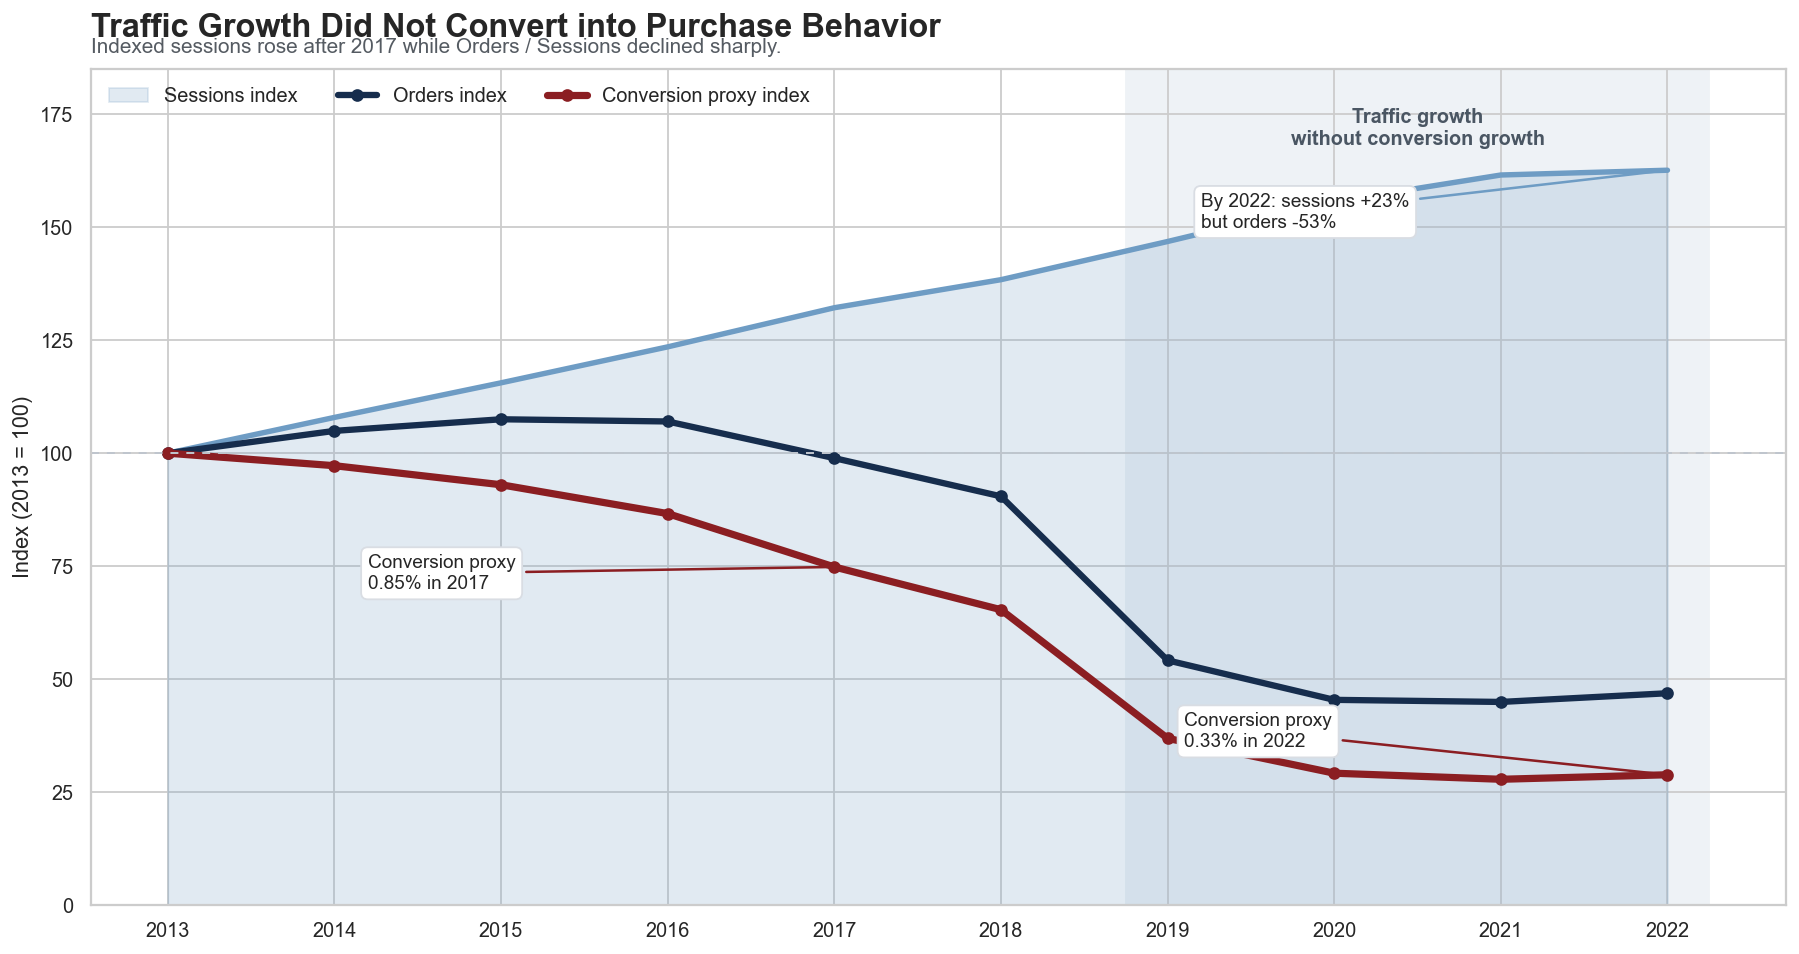

In [5]:
fig, ax1 = plt.subplots(figsize=(14, 7.5))
ax1.set_title("Traffic Growth Did Not Convert into Purchase Behavior", loc="left", fontsize=18, fontweight="bold", pad=18)
ax1.text(0, 1.02, "Indexed sessions rose after 2017 while Orders / Sessions declined sharply.", transform=ax1.transAxes, fontsize=11.5, color="#555B62")

ax1.axvspan(2018.75, 2022.25, color="#EEF2F6", zorder=0)
ax1.text(2020.5, 172, "Traffic growth\nwithout conversion growth", ha="center", va="center", fontsize=11, fontweight="bold", color="#4A5663")

ax1.fill_between(annual["Year"], annual["sessions_index"], 0, color="#7EA6C8", alpha=0.23, label="Sessions index")
ax1.plot(annual["Year"], annual["sessions_index"], color="#6E9CC4", linewidth=3)
ax1.plot(annual["Year"], annual["orders_index"], color="#162D4D", linewidth=3.5, marker="o", label="Orders index")
ax1.plot(annual["Year"], annual["conversion_proxy_index"], color="#8B1E22", linewidth=4, marker="o", label="Conversion proxy index")

ax1.axhline(100, color="#BFC5CD", linewidth=1.1, linestyle=(0, (4, 4)))
ax1.set_ylabel("Index (2013 = 100)")
ax1.set_xlabel("")
ax1.set_xticks(range(2013, 2023))
ax1.set_ylim(0, 185)
ax1.legend(loc="upper left", frameon=False, ncol=3)

ax1.annotate(
    f"Conversion proxy\n{cp_2017:.2f}% in 2017",
    xy=(2017, annual.loc[annual["Year"].eq(2017), "conversion_proxy_index"].iloc[0]),
    xytext=(2014.2, 70),
    arrowprops=dict(arrowstyle="-", color="#8B1E22", lw=1.4),
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#D9DDE3"),
    fontsize=10.5,
)
ax1.annotate(
    f"By 2022: sessions +{sessions_2017_2022:.0f}%\nbut orders {orders_2017_2022:.0f}%",
    xy=(2022, annual.loc[annual["Year"].eq(2022), "sessions_index"].iloc[0]),
    xytext=(2019.2, 150),
    arrowprops=dict(arrowstyle="-", color="#6E9CC4", lw=1.4),
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#D9DDE3"),
    fontsize=10.5,
)
ax1.annotate(
    f"Conversion proxy\n{cp_2022:.2f}% in 2022",
    xy=(2022, annual.loc[annual["Year"].eq(2022), "conversion_proxy_index"].iloc[0]),
    xytext=(2019.1, 35),
    arrowprops=dict(arrowstyle="-", color="#8B1E22", lw=1.4),
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#D9DDE3"),
    fontsize=10.5,
)

fig.tight_layout()
fig.savefig(OUT_DIR / "conversion_proxy_sessions_orders_index.png", bbox_inches="tight")
plt.show()


## 5. Monthly Evidence: The Decline Is Persistent, Not a Single-Year Artifact

Monthly conversion proxy smooths daily noise and shows whether the deterioration is sustained during the traffic expansion period.


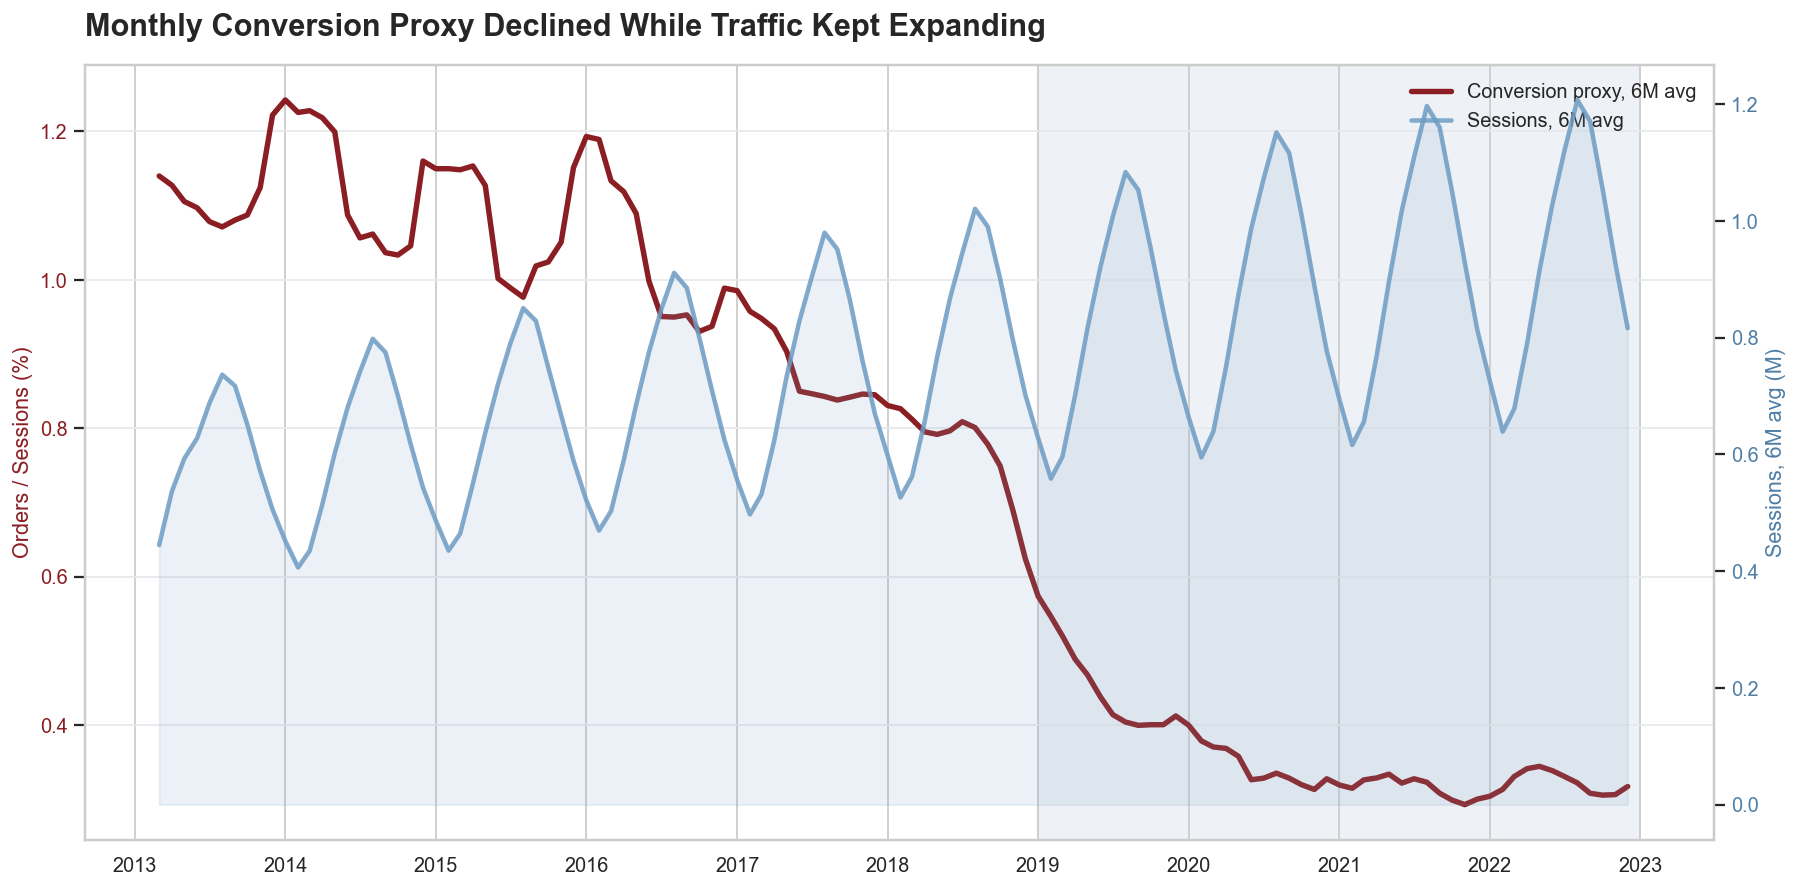

In [6]:
monthly_plot = monthly.query("Month >= '2013-01-01'").copy()
monthly_plot["conversion_proxy_pct"] = monthly_plot["conversion_proxy"] * 100
monthly_plot["conversion_proxy_6m"] = monthly_plot["conversion_proxy_pct"].rolling(6, min_periods=3).mean()
monthly_plot["sessions_6m"] = monthly_plot["sessions"].rolling(6, min_periods=3).mean()

fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.set_title("Monthly Conversion Proxy Declined While Traffic Kept Expanding", loc="left", fontsize=17, fontweight="bold", pad=16)
ax1.axvspan(pd.Timestamp("2019-01-01"), pd.Timestamp("2022-12-31"), color="#EEF2F6", zorder=0)

ax1.plot(monthly_plot["Month"], monthly_plot["conversion_proxy_6m"], color="#8B1E22", linewidth=3, label="Conversion proxy, 6M avg")
ax1.set_ylabel("Orders / Sessions (%)", color="#8B1E22")
ax1.tick_params(axis="y", labelcolor="#8B1E22")
ax1.grid(axis="y", color="#E7E9ED")

ax2 = ax1.twinx()
ax2.plot(monthly_plot["Month"], monthly_plot["sessions_6m"] / 1_000_000, color="#6E9CC4", linewidth=2.5, alpha=0.85, label="Sessions, 6M avg")
ax2.fill_between(monthly_plot["Month"], monthly_plot["sessions_6m"] / 1_000_000, color="#7EA6C8", alpha=0.15)
ax2.set_ylabel("Sessions, 6M avg (M)", color="#4F7EA6")
ax2.tick_params(axis="y", labelcolor="#4F7EA6")
ax2.grid(False)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper right", frameon=False)

fig.tight_layout()
fig.savefig(OUT_DIR / "conversion_proxy_monthly_trend.png", bbox_inches="tight")
plt.show()


## 6. Traffic Source Lens

Because `traffic_source` and `order_source` use the same source taxonomy, a source-level proxy can test whether the issue is broad-based or concentrated in acquisition channels.

This is still a proxy, not user-level attribution: it compares source-level order volume and source-level sessions over the same period.


In [7]:
traffic_source = (
    traffic.assign(Year=traffic["date"].dt.year)
    .groupby(["Year", "traffic_source"], as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        avg_bounce_rate=("bounce_rate", "mean"),
        avg_session_duration_sec=("avg_session_duration_sec", "mean"),
    )
    .rename(columns={"traffic_source": "source"})
)

order_source = (
    orders.assign(Year=orders["order_date"].dt.year)
    .groupby(["Year", "order_source"], as_index=False)
    .agg(orders=("order_id", "nunique"))
    .rename(columns={"order_source": "source"})
)

source_annual = traffic_source.merge(order_source, on=["Year", "source"], how="left").fillna({"orders": 0})
source_annual = source_annual.query("Year >= 2013 and Year <= 2022").copy()
source_annual["conversion_proxy"] = source_annual["orders"] / source_annual["sessions"]
source_annual["conversion_proxy_pct"] = source_annual["conversion_proxy"] * 100

source_summary = (
    source_annual.pivot_table(index="source", columns="Year", values="conversion_proxy_pct")
    .assign(
        change_2017_to_2022_pct=lambda x: (x[2022] / x[2017] - 1) * 100,
        change_2019_to_2022_pct=lambda x: (x[2022] / x[2019] - 1) * 100,
    )
    .sort_values("change_2017_to_2022_pct")
)
source_summary.round(3)


Year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,change_2017_to_2022_pct,change_2019_to_2022_pct
source,,,,,,,,,,,,
organic_search,0.978,1.144,0.956,1.041,0.850,0.704,0.405,0.313,0.275,0.280,-67.031,-30.876
paid_search,1.157,0.974,1.066,0.980,0.831,0.843,0.437,0.339,0.380,0.298,-64.088,-31.817
social_media,1.085,1.262,1.154,1.057,0.949,0.879,0.485,0.519,0.387,0.351,-63.011,-27.675
direct,1.076,0.890,1.978,1.539,0.968,0.651,0.502,0.398,0.285,0.417,-56.889,-16.798
email_campaign,1.529,1.254,0.986,0.657,0.723,0.547,0.320,0.211,0.305,0.349,-51.702,9.188
referral,1.388,1.040,0.850,0.947,0.772,0.789,0.381,0.295,0.257,0.427,-44.652,12.207


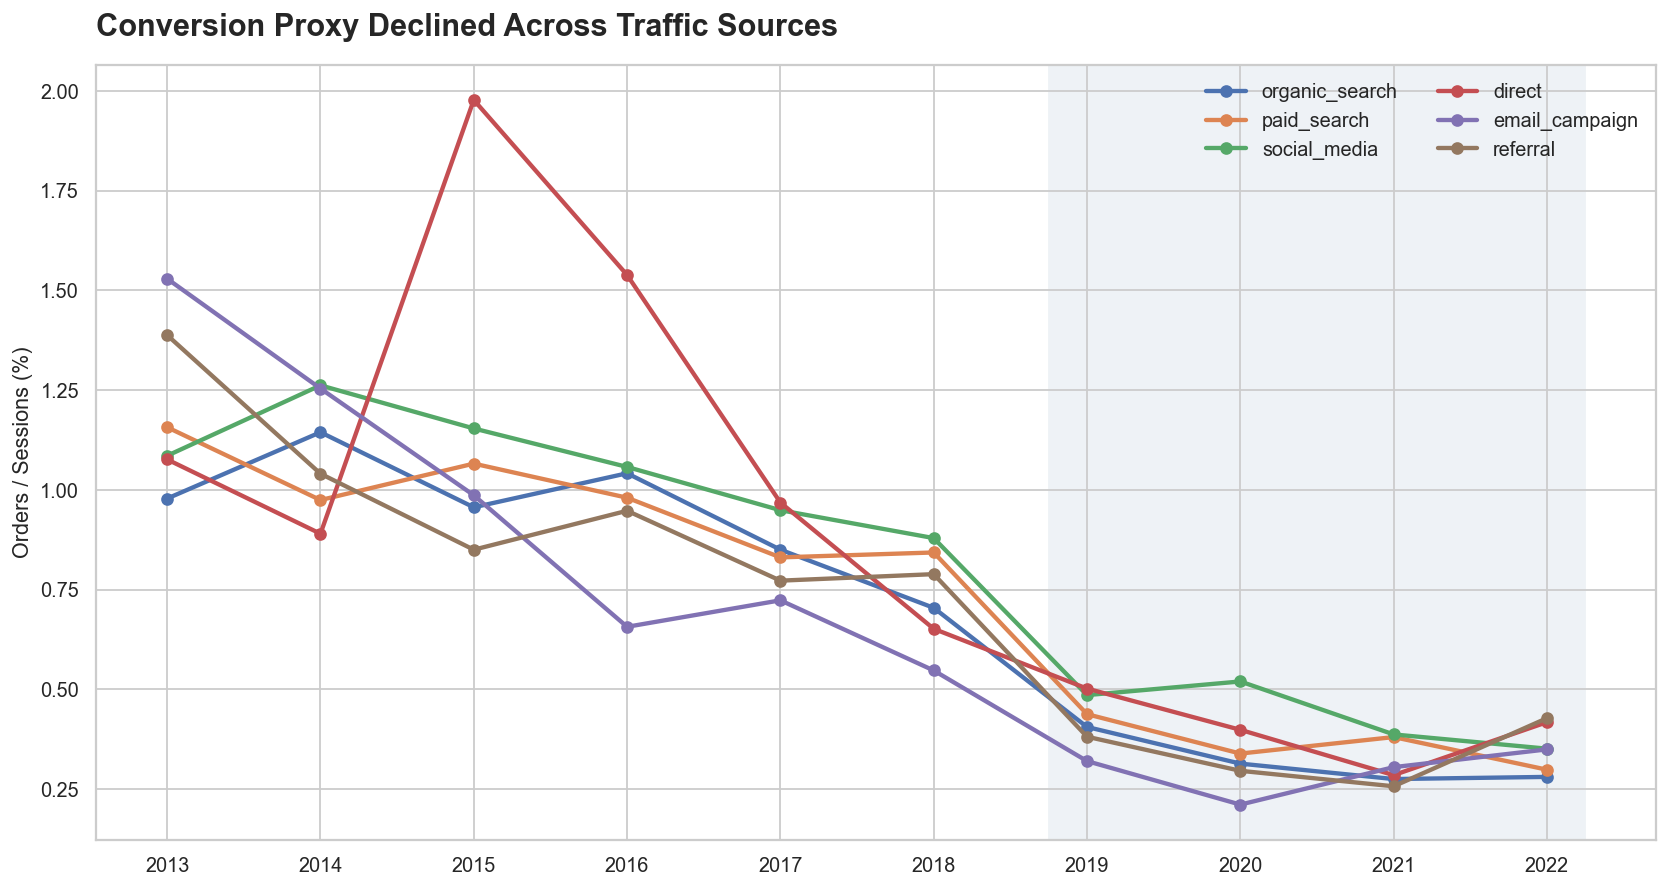

In [8]:
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_title("Conversion Proxy Declined Across Traffic Sources", loc="left", fontsize=17, fontweight="bold", pad=16)

source_order = source_summary.index.tolist()
for source in source_order:
    temp = source_annual[source_annual["source"].eq(source)]
    ax.plot(temp["Year"], temp["conversion_proxy_pct"], marker="o", linewidth=2.4, label=source)

ax.axvspan(2018.75, 2022.25, color="#EEF2F6", zorder=0)
ax.set_ylabel("Orders / Sessions (%)")
ax.set_xlabel("")
ax.set_xticks(range(2013, 2023))
ax.legend(loc="upper right", frameon=False, ncol=2)

fig.tight_layout()
fig.savefig(OUT_DIR / "conversion_proxy_by_source.png", bbox_inches="tight")
plt.show()


## 7. Statistical Checks

These checks are descriptive. They quantify whether traffic volume and conversion proxy move in opposite directions during the post-2017 deterioration period.


In [9]:
post_2017 = annual.query("Year >= 2017").copy()
pearson_r, pearson_p = stats.pearsonr(post_2017["sessions"], post_2017["conversion_proxy"])
spearman_r, spearman_p = stats.spearmanr(post_2017["sessions"], post_2017["conversion_proxy"])

checks = pd.DataFrame({
    "check": [
        "Pearson correlation: sessions vs conversion proxy, 2017-2022",
        "Spearman correlation: sessions vs conversion proxy, 2017-2022",
        "Average conversion proxy, 2013-2017",
        "Average conversion proxy, 2019-2022",
        "Average revenue per session index, 2013-2017",
        "Average revenue per session index, 2019-2022",
    ],
    "value": [
        pearson_r,
        spearman_r,
        annual.query("Year <= 2017")["conversion_proxy_pct"].mean(),
        annual.query("Year >= 2019")["conversion_proxy_pct"].mean(),
        annual.query("Year <= 2017")["revenue_per_session_index"].mean(),
        annual.query("Year >= 2019")["revenue_per_session_index"].mean(),
    ],
    "p_value_if_applicable": [
        pearson_p,
        spearman_p,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
    ],
})
checks.round(4)


,check,value,p_value_if_applicable
0,Pearson correlation: sessions vs conversion pr...,-0.9481,0.0040
1,Spearman correlation: sessions vs conversion p...,-0.9429,0.0048
2,"Average conversion proxy, 2013-2017",1.0207,NaN
3,"Average conversion proxy, 2019-2022",0.3463,NaN
4,"Average revenue per session index, 2013-2017",98.6723,NaN
5,"Average revenue per session index, 2019-2022",42.4801,NaN


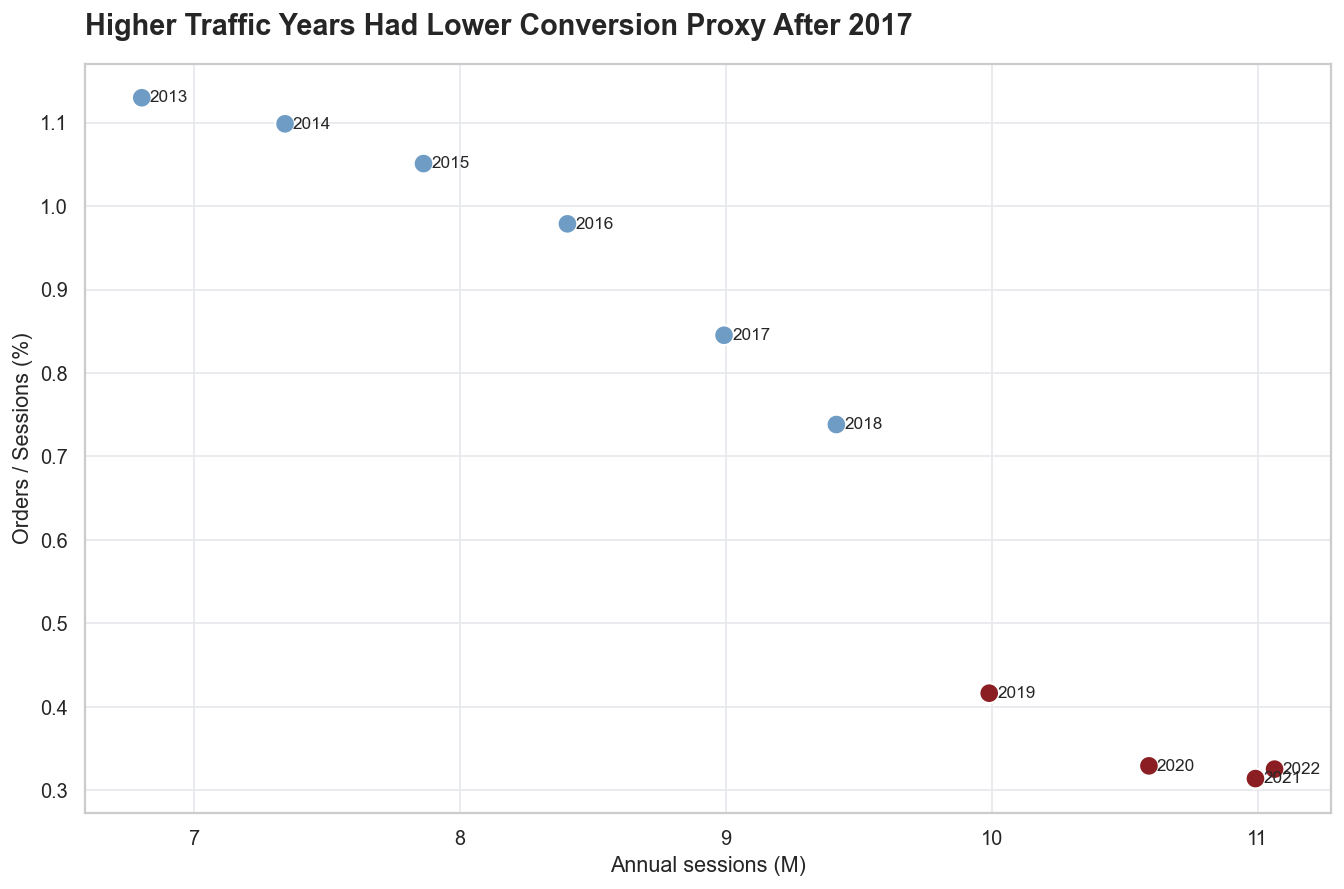

In [10]:
fig, ax = plt.subplots(figsize=(10.5, 7))
ax.set_title("Higher Traffic Years Had Lower Conversion Proxy After 2017", loc="left", fontsize=16, fontweight="bold", pad=16)

colors = np.where(annual["Year"] >= 2019, "#8B1E22", "#6E9CC4")
ax.scatter(annual["sessions"] / 1_000_000, annual["conversion_proxy_pct"], s=120, c=colors, edgecolor="white", linewidth=1.2)
for _, row in annual.iterrows():
    ax.text(row["sessions"] / 1_000_000 + 0.03, row["conversion_proxy_pct"], int(row["Year"]), va="center", fontsize=9.5)

ax.set_xlabel("Annual sessions (M)")
ax.set_ylabel("Orders / Sessions (%)")
ax.grid(True, color="#E7E9ED")

fig.tight_layout()
fig.savefig(OUT_DIR / "sessions_vs_conversion_proxy_scatter.png", bbox_inches="tight")
plt.show()


## 8. Sensitivity: Completed-Order Conversion Proxy

To ensure the signal is not only caused by cancelled or returned orders, the same proxy is recalculated using completed-like statuses: `delivered`, `shipped`, and `paid`.


In [11]:
sensitivity = annual[[
    "Year",
    "conversion_proxy_pct",
    "completed_conversion_proxy_pct",
    "conversion_proxy_index",
    "completed_conversion_proxy_index",
]].copy()
sensitivity["gap_bps"] = (sensitivity["conversion_proxy_pct"] - sensitivity["completed_conversion_proxy_pct"]) * 100
sensitivity.round(3)


,Year,conversion_proxy_pct,completed_conversion_proxy_pct,conversion_proxy_index,completed_conversion_proxy_index,gap_bps
0,2013,1.130,0.950,100.000,100.000,17.971
1,2014,1.099,0.927,97.234,97.542,17.182
2,2015,1.051,0.884,93.017,93.063,16.673
3,2016,0.979,0.824,86.628,86.771,15.433
4,2017,0.845,0.713,74.813,75.074,13.198
5,2018,0.738,0.622,65.346,65.442,11.653
6,2019,0.416,0.350,36.858,36.864,6.618
7,2020,0.329,0.277,29.150,29.145,5.244
8,2021,0.314,0.262,27.801,27.538,5.247
9,2022,0.325,0.270,28.804,28.391,5.569


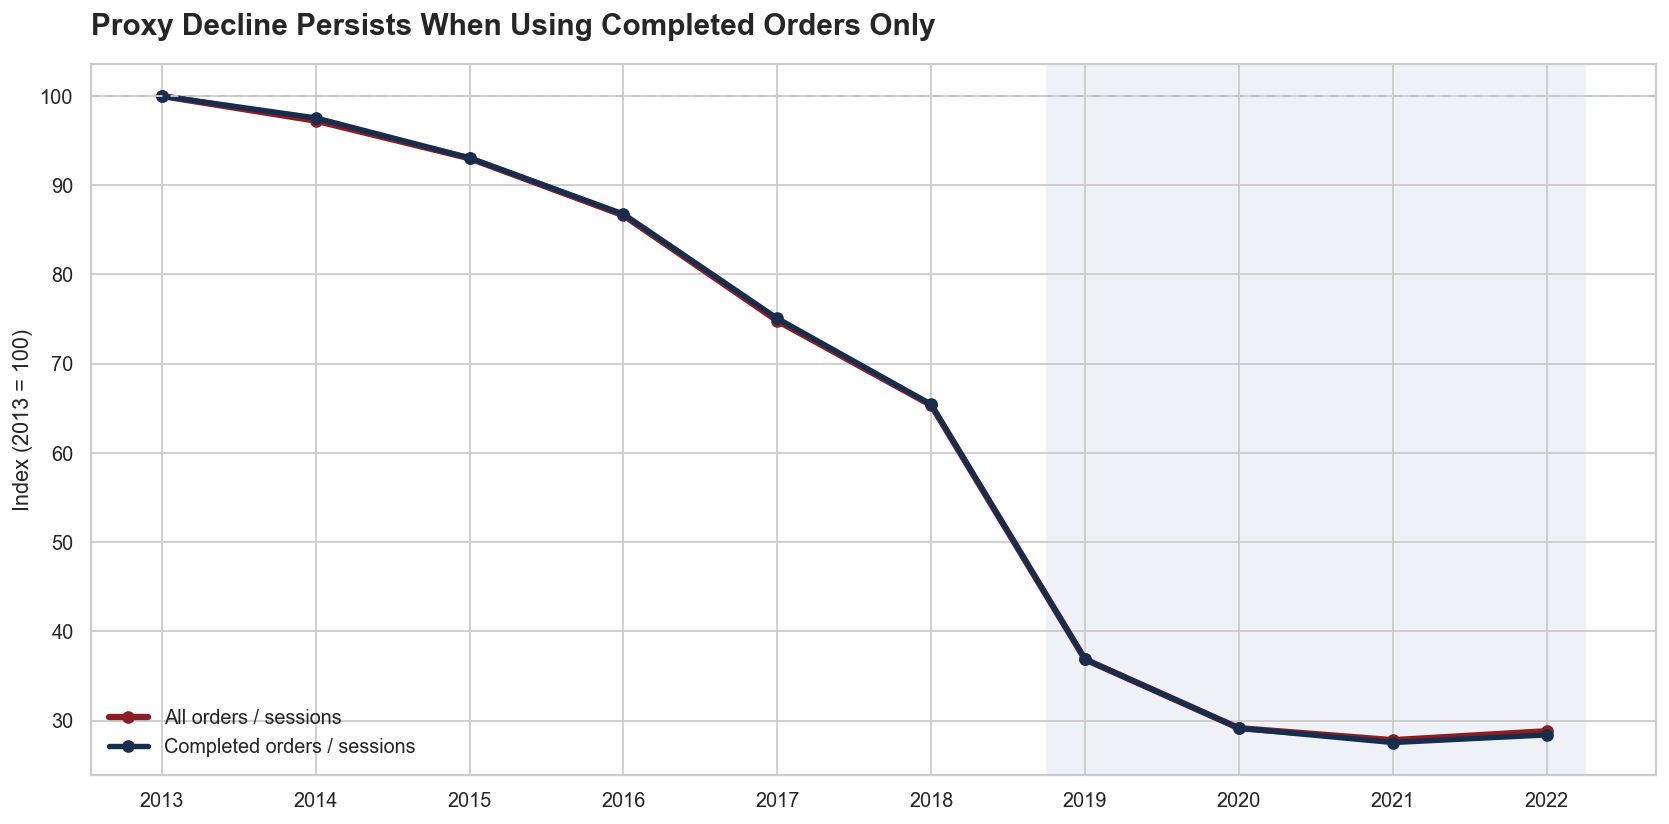

In [12]:
fig, ax = plt.subplots(figsize=(13, 6.5))
ax.set_title("Proxy Decline Persists When Using Completed Orders Only", loc="left", fontsize=16.5, fontweight="bold", pad=16)
ax.axvspan(2018.75, 2022.25, color="#EEF2F6", zorder=0)

ax.plot(annual["Year"], annual["conversion_proxy_index"], color="#8B1E22", marker="o", linewidth=3.5, label="All orders / sessions")
ax.plot(annual["Year"], annual["completed_conversion_proxy_index"], color="#162D4D", marker="o", linewidth=3, label="Completed orders / sessions")
ax.axhline(100, color="#BFC5CD", linewidth=1.1, linestyle=(0, (4, 4)))
ax.set_ylabel("Index (2013 = 100)")
ax.set_xticks(range(2013, 2023))
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(OUT_DIR / "conversion_proxy_completed_order_sensitivity.png", bbox_inches="tight")
plt.show()


## 9. Conclusion for Report Narrative

Evidence supporting the claim:

- Sessions continued growing after 2017.
- Orders did not follow sessions; they fell materially from the pre-2017 level.
- `Orders / Sessions` declined sharply during the same period, indicating lower conversion quality.
- Revenue per session also deteriorated, confirming that traffic growth did not translate into monetization.
- Source-level analysis shows the proxy decline is broad-based, not isolated to a single channel.
- Completed-order sensitivity preserves the same downward pattern.

Suggested report wording:

> Traffic growth increasingly decoupled from purchase behavior after 2017. The conversion proxy, measured as Orders / Sessions, declined materially while sessions kept rising, indicating that incremental traffic was lower-intent or less effectively converted into orders.

Limitations:

- This is a proxy, not user-level funnel attribution.
- Source-level analysis assumes `traffic_source` and `order_source` are comparable acquisition labels.
- Session quality should ideally be validated with funnel events such as product views, add-to-cart, checkout starts, and user-level attribution if available.
